In [1]:
import pandas as pd
df = pd.read_csv("stroke.csv")

In [2]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:


print("FIRST 5 ROWS")
print(df.head())

print("\nLAST 5 ROWS")
print(df.tail())

print("\nSHAPE")
print(df.shape)

print("\nCOLUMNS")
print(df.columns)

print("\nINFO")
print(df.info())

print("\nDescriptive statistics :")
df.describe()

FIRST 5 ROWS
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

LAST 5 ROWS
         id  gender   age  hyp

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [4]:
df.shape

(5110, 12)

In [5]:
print("\nMissing value count per column:")
print(df.isnull().sum())


Missing value count per column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [6]:
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [7]:
df=df.drop_duplicates()

df.duplicated().sum()
print("Stroke distribution:")
print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True) * 100)

Stroke distribution:
stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


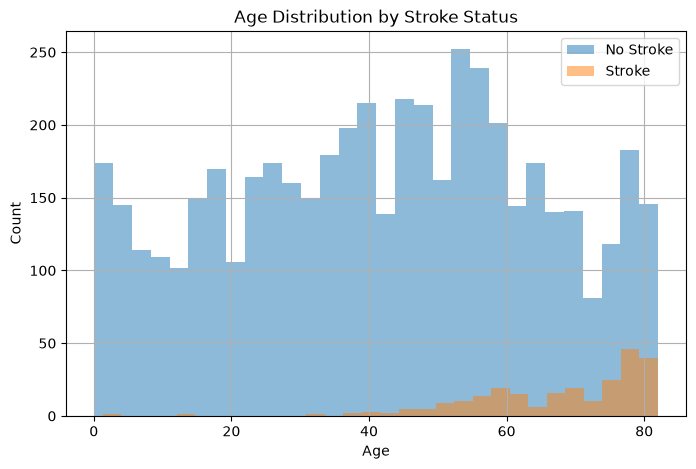

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df[df['stroke']==0]['age'].hist(alpha=0.5, label='No Stroke', bins=30)
df[df['stroke']==1]['age'].hist(alpha=0.5, label='Stroke', bins=30)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Stroke Status')
plt.legend()
plt.show()

In [9]:
print("Stroke rate by hypertension:")
print(df.groupby('hypertension')['stroke'].mean() * 100)

print("\nStroke rate by heart disease:")
print(df.groupby('heart_disease')['stroke'].mean() * 100)

Stroke rate by hypertension:
hypertension
0     3.967910
1    13.253012
Name: stroke, dtype: float64

Stroke rate by heart disease:
heart_disease
0     4.178734
1    17.028986
Name: stroke, dtype: float64


In [10]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [11]:
df['age'] = df['age'].astype(int)
df['gender'] = df['gender'].astype(str)
df['ever_married'] = df['ever_married'].astype(str)
df['work_type'] = df['work_type'].astype(str)
df['Residence_type'] = df['Residence_type'].astype(str)
df['smoking_status'] = df['smoking_status'].astype(str) 

In [12]:






Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['bmi'] < lower) | (df['bmi'] > upper)]

print(f"bmi: {len(outliers)} outliers")
outliers[['id','age', 'bmi','stroke','avg_glucose_level']]

bmi: 126 outliers


,id,age,bmi,stroke,avg_glucose_level
21,13861,52,48.9,1,233.29
66,17004,70,47.5,1,221.58
113,41069,45,56.6,1,224.10
254,32257,47,50.1,0,210.95
258,28674,74,54.6,0,205.84
...,...,...,...,...,...
4906,72696,53,54.1,0,70.51
4952,16245,51,56.6,0,211.83
5009,40732,50,49.5,0,126.85
5057,38349,49,47.6,0,69.92


In [13]:

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower) | (df['age'] > upper)]

print(f"age: {len(outliers)} outliers")
outliers[['id','age', 'bmi','stroke','avg_glucose_level']]

age: 0 outliers


,id,age,bmi,stroke,avg_glucose_level


In [14]:

Q1 = df['avg_glucose_level'].quantile(0.25)
Q3 = df['avg_glucose_level'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['avg_glucose_level'] < lower) | (df['avg_glucose_level'] > upper)]

print(f"avg_glucose_level: {len(outliers)} outliers")
outliers[['id','age', 'bmi','stroke','avg_glucose_level']]

avg_glucose_level: 627 outliers


,id,age,bmi,stroke,avg_glucose_level
0,9046,67,36.600000,1,228.69
1,51676,61,28.893237,1,202.21
3,60182,49,34.400000,1,171.23
4,1665,79,24.000000,1,174.12
5,56669,81,29.000000,1,186.21
...,...,...,...,...,...
5061,38009,41,32.300000,0,223.78
5062,11184,82,36.900000,0,211.58
5063,68967,39,27.700000,0,179.38
5064,66684,70,24.300000,0,193.88


In [15]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


In [16]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [17]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [18]:
df['hypertension'].value_counts()

hypertension
0    4612
1     498
Name: count, dtype: int64

In [19]:
df['heart_disease'].value_counts()

heart_disease
0    4834
1     276
Name: count, dtype: int64

In [20]:
df['ever_married'].value_counts()

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

In [21]:
df['smoking_status'].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [22]:
df['Residence_type'].value_counts()

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

In [23]:
df['work_type'].value_counts()

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [24]:
df = df.drop(columns=['id'])

In [25]:
df = pd.get_dummies(df, columns=['gender', 'work_type'],drop_first=True   )
print(df.head())
print(df.shape)

   age  hypertension  heart_disease ever_married Residence_type  \
0   67             0              1          Yes          Urban   
1   61             0              0          Yes          Rural   
2   80             0              1          Yes          Rural   
3   49             0              0          Yes          Urban   
4   79             1              0          Yes          Rural   

   avg_glucose_level        bmi   smoking_status  stroke  gender_Male  \
0             228.69  36.600000  formerly smoked       1         True   
1             202.21  28.893237     never smoked       1        False   
2             105.92  32.500000     never smoked       1         True   
3             171.23  34.400000           smokes       1        False   
4             174.12  24.000000     never smoked       1        False   

   gender_Other  work_type_Never_worked  work_type_Private  \
0         False                   False               True   
1         False                   

In [26]:

df = df.astype({col: int for col in df.select_dtypes(bool).columns})

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['ever_married'] = le.fit_transform(df['ever_married'])
df['Residence_type'] = le.fit_transform(df['Residence_type'])

print(df[['ever_married', 'Residence_type']].head())

   ever_married  Residence_type
0             1               1
1             1               0
2             1               0
3             1               1
4             1               0


In [28]:
smoking_map = {
    'Unknown': 0,
    'never smoked': 1,
    'formerly smoked': 2,
    'smokes': 3
}

df['smoking_status'] = df['smoking_status'].map(smoking_map)

print(df['smoking_status'])

0       2
1       1
2       1
3       3
4       1
       ..
5105    1
5106    1
5107    1
5108    2
5109    0
Name: smoking_status, Length: 5110, dtype: int64


In [29]:
df.head()

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,gender_Male,gender_Other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children
0,67,0,1,1,1,228.69,36.600000,2,1,1,0,0,1,0,0
1,61,0,0,1,0,202.21,28.893237,1,1,0,0,0,0,1,0
2,80,0,1,1,0,105.92,32.500000,1,1,1,0,0,1,0,0
3,49,0,0,1,1,171.23,34.400000,3,1,0,0,0,1,0,0
4,79,1,0,1,0,174.12,24.000000,1,1,0,0,0,0,1,0


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = ['age', 'bmi', 'avg_glucose_level']
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print(df[scale_cols].head())

        age           bmi  avg_glucose_level
0  1.050950  1.001234e+00           2.706375
1  0.785835  4.615554e-16           2.121559
2  1.625367  4.685773e-01          -0.005028
3  0.255604  7.154182e-01           1.437358
4  1.581181 -6.357112e-01           1.501184


In [35]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nStroke % in train:", y_train.mean() * 100)
print("Stroke % in test:", y_test.mean() * 100)

Train shape: (4088, 14)
Test shape: (1022, 14)

Stroke % in train: 4.867906066536203
Stroke % in test: 4.892367906066536


In [34]:
print(df.columns.tolist())

['age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke', 'gender_Male', 'gender_Other', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children']


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[719 253]
 [ 10  40]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.82      1022



In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced_subsample', random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRandom Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest - Confusion Matrix:
[[971   1]
 [ 50   0]]

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



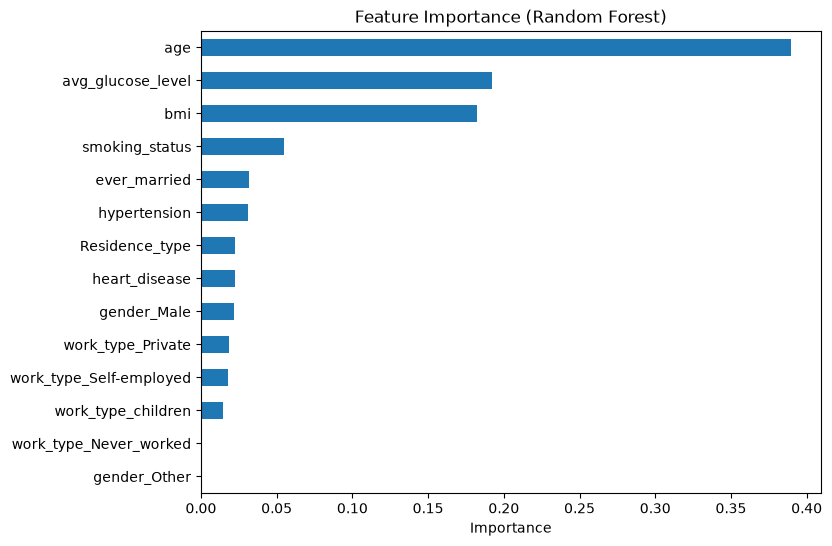

In [39]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

In [40]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[941  31]
 [ 42   8]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.21      0.16      0.18        50

    accuracy                           0.93      1022
   macro avg       0.58      0.56      0.57      1022
weighted avg       0.92      0.93      0.92      1022



In [42]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 3889, 1: 199}
After SMOTE: {0: 3889, 1: 3889}


In [43]:
rf_smote = RandomForestClassifier(random_state=42, n_estimators=200)
rf_smote.fit(X_train_sm, y_train_sm)

y_pred_smote = rf_smote.predict(X_test)

print("Random Forest + SMOTE - Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nRandom Forest + SMOTE - Classification Report:")
print(classification_report(y_test, y_pred_smote))

Random Forest + SMOTE - Confusion Matrix:
[[891  81]
 [ 39  11]]

Random Forest + SMOTE - Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       972
           1       0.12      0.22      0.15        50

    accuracy                           0.88      1022
   macro avg       0.54      0.57      0.55      1022
weighted avg       0.92      0.88      0.90      1022



## Conclusion

- Analyzed 5000+ patient records to identify stroke risk factors
- Found stroke incidence is 4.9%, requiring class-imbalance-aware modeling
- Age, hypertension, and heart disease emerged as strongest risk indicators
  (hypertension: 3.3x higher stroke rate, heart disease: 4x higher)
- Compared two models:
  - Logistic Regression (class_weight='balanced'): 80% recall on stroke detection
  - Random Forest (class_weight='balanced_subsample'): 0% recall — defaulted to 
    majority class despite balancing, showing tree-based models need extra handling 
    (e.g. SMOTE oversampling) for severely imbalanced data
- Logistic Regression was the better choice here, since catching stroke cases 
  matters more than raw accuracy
- Next steps: try SMOTE oversampling with Random Forest, and threshold tuning 
  to improve precision on the Logistic Regression model
Despite trying SMOTE to fix Random Forest's poor recall, Logistic Regression 
with balanced class weighting remained the best model for this task — showing 
that for severely imbalanced healthcare data, simpler weighted linear models 
can outperform more complex tree ensembles.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 3889, 1: 199}
After SMOTE: {0: 3889, 1: 3889}
